In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")
from skrmt.denoise.mp_pca import MarchenkoPasturPCADenoiser

from denoise_rmt import average_ssim, average_psnr, average_snr

In [3]:
def plot_slices(slices, titles=None, cmap="gray", origin="lower"):
    """Function to display a row of image slices."""
    n_slices = len(slices)
    fig, axes = plt.subplots(1, n_slices, figsize=(3.5 * n_slices, 3.8))

    if len(slices) > 1:
        for i, slice_array in enumerate(slices):
            axes[i].imshow(slice_array, cmap=cmap, origin=origin, aspect="auto")
            if titles is not None:
                axes[i].set_title(titles[i])
            axes[i].grid(False)
    else:
        axes.imshow(slices[0], cmap=cmap, origin=origin)
        if titles is not None:
            axes.set_title(titles[0])
        axes.grid(False)

In [4]:
tumor_slice = np.load("sim_data/sample_tumor_img.npy")
tumor_slice.shape

(184, 132)

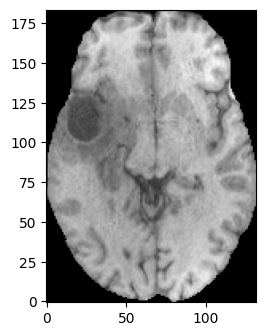

In [5]:
plot_slices([tumor_slice])

In [6]:
pad_tumor_slice = np.pad(tumor_slice, pad_width=5, mode="constant", constant_values=0)
pad_tumor_slice.shape

(194, 142)

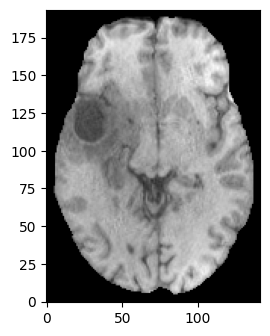

In [7]:
# Title: "Original brain slice"
plot_slices([pad_tumor_slice])

In [8]:
from denoise_rmt import ImgNoiseCorruptor

noise_corruptor = ImgNoiseCorruptor(original_img=pad_tumor_slice)

In [9]:
# Simulation parameters
n_snapshots = 100
random_seed = 1

# Noise parameters
sigma = 35  # Marchenko-Pastur sigma ~ noise standard deviation
rice_b = 2  # Rice distribution parameter

# Generate noisy snapshot and foreground mask
snapshots, fg_masks = noise_corruptor.generate_rician_noisy_displaced_imgs(
    n_snapshots=n_snapshots,
    rice_b=rice_b,
    sigma=sigma,
    seed=random_seed,
)
snapshot = snapshots[0]
fg_mask = fg_masks[0]

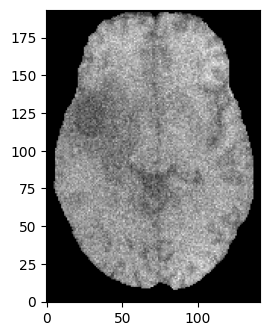

In [10]:
# Title: "Sample of corrupted image"
plot_slices([snapshot])

Denoising 100 snapshots of size 194x142 (sigma = 35, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


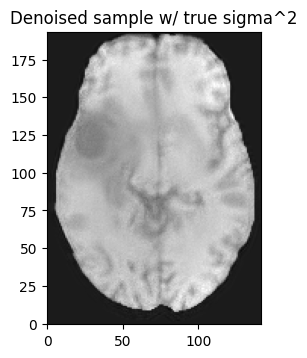

In [11]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma=sigma)

denoised_snapshots_true_sigma = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_true_sigma.shape}")
plot_slices([denoised_snapshots_true_sigma[0]], titles=["Denoised sample w/ true sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'median' -> sigma_ = 28.8463, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


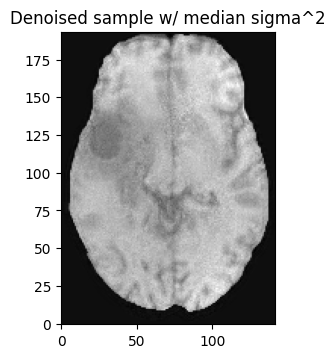

In [12]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="median")

denoised_snapshots_median = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_median.shape}")
plot_slices([denoised_snapshots_median[0]], titles=["Denoised sample w/ median sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'bulk_mean' -> sigma_ = 200.066, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


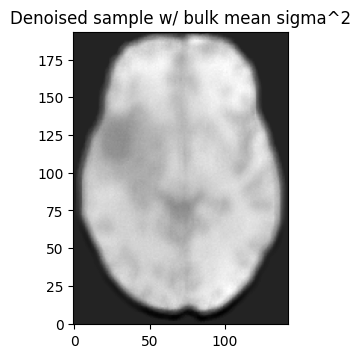

In [13]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="bulk_mean")

denoised_snapshots_bulk_mean = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_bulk_mean.shape}")
plot_slices([denoised_snapshots_bulk_mean[0]], titles=["Denoised sample w/ bulk mean sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'min_eigen' -> sigma_ = 26.8983, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


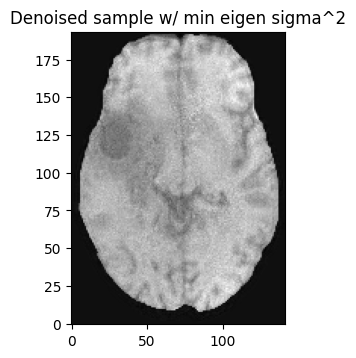

In [14]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="min_eigen")

denoised_snapshots_min_eigen = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_min_eigen.shape}")
plot_slices([denoised_snapshots_min_eigen[0]], titles=["Denoised sample w/ min eigen sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'mp_fit' -> sigma_ = 26.4722, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


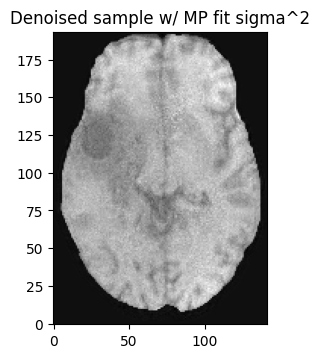

In [15]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="mp_fit")

denoised_snapshots_mp_fit = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_mp_fit.shape}")
plot_slices([denoised_snapshots_mp_fit[0]], titles=["Denoised sample w/ MP fit sigma^2"])

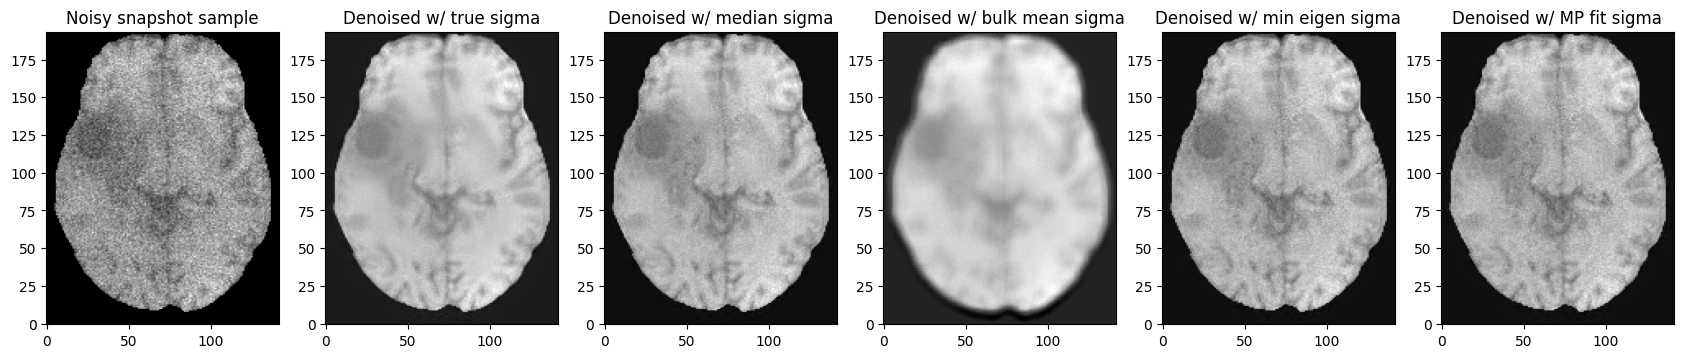

In [16]:
plot_slices(
    [
        snapshots[0],
        denoised_snapshots_true_sigma[0],
        denoised_snapshots_median[0],
        denoised_snapshots_bulk_mean[0],
        denoised_snapshots_min_eigen[0],
        denoised_snapshots_mp_fit[0],
    ],
    titles=[
        "Noisy snapshot sample",
        "Denoised w/ true sigma",
        "Denoised w/ median sigma",
        "Denoised w/ bulk mean sigma",
        "Denoised w/ min eigen sigma",
        "Denoised w/ MP fit sigma",
    ],
)

In [17]:
print("\nAverage SNR:")
print(f"Noisy snapshots: {average_snr(ref_img=pad_tumor_slice, test_imgs=snapshots)}")
print(f"True sigma: {average_snr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")
print(f"Median sigma: {average_snr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Bulk mean sigma: {average_snr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_bulk_mean)}")
print(f"Min eigen sigma: {average_snr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_snr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")


Average SNR:
Noisy snapshots: (4.357015139513695, 0.5381883909087838)
True sigma: (10.52943707734743, 1.5342719591132552)
Median sigma: (11.096526916038254, 1.7073864951191462)
Bulk mean sigma: (9.654650068893124, 1.5048131796544373)
Min eigen sigma: (11.34982406318713, 1.8301935148318504)
MP fit sigma: (11.398570432626421, 1.856537678251161)


In [20]:
print("Average PSNR:")
print(f"Noisy snapshots: {average_psnr(ref_img=pad_tumor_slice, test_imgs=snapshots)}")
print(f"True sigma: {average_psnr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")
print(f"Median sigma: {average_psnr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Bulk mean sigma: {average_psnr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_bulk_mean)}")
print(f"Min eigen sigma: {average_psnr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_psnr(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")

Average PSNR:
Noisy snapshots: (9.994951880143695, 0.5381883909087837)
True sigma: (16.167373817977428, 1.5342719591132556)
Median sigma: (16.734463656668257, 1.7073864951191464)
Bulk mean sigma: (15.292586809523128, 1.5048131796544373)
Min eigen sigma: (16.987760803817135, 1.8301935148318507)
MP fit sigma: (17.036507173256418, 1.856537678251161)


In [21]:
print("Average SSIM:")
print(f"Noisy snapshots: {average_ssim(ref_img=pad_tumor_slice, test_imgs=snapshots)}")
print(f"True sigma: {average_ssim(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")
print(f"Median sigma: {average_ssim(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Bulk mean sigma: {average_ssim(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_bulk_mean)}")
print(f"Min eigen sigma: {average_ssim(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_ssim(ref_img=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")

Average SSIM:


Noisy snapshots: (0.3062995190676518, 0.08089437030608228)
True sigma: (0.3665456976648907, 0.13316320120768416)
Median sigma: (0.32455792143473056, 0.13648519675302392)
Bulk mean sigma: (0.4498104109993066, 0.06820882595605547)
Min eigen sigma: (0.3006915752095534, 0.1306753064175651)
MP fit sigma: (0.2955814570852394, 0.12921045477045406)
